# Backpropagation for AND logic

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Initialize dataset

x = np.array([[0,0],[0,1],[1,0],[1,1]]).T
y = np.array([0,0,0,1])

In [6]:
# initialize parameters
def initialize_parameters():
    input_size = 2
    hidden_size = 2
    output_size = 1
    learning_rate = 0.2
    epochs = 1000000

    w1 = np.random.rand(hidden_size, input_size) * 2 - 1
    b1 = np.random.rand(hidden_size, 1) * 2 - 1

    w2 = np.random.rand(output_size, hidden_size) * 2 - 1
    b2 = np.random.rand(output_size, 1) * 2 - 1

    return w1, w2, b1, b2, learning_rate, epochs

In [8]:
# backpropagation algorithm

w1, w2, b1, b2, lr, epochs = initialize_parameters()
error_list = []

for epoch in range(epochs):
    
    z1 = np.dot(w1,x) + b1
    a1 = 1 / (1 + np.exp(-z1))
    
    z2 = np.dot(w2, a1) + b2
    a2 = 1 / (1 + np.exp(-z2))
    
    
    # derivative deines
    error = y - a2
    da2 = error * (a2* (1-a2))
    dz2 = da2
    
    da1 = np.dot(w2.T,dz2)
    dz1 = da1 * (a1 * (1-a1))
    
    
    #weights and bias updation
    w2 = w2 + lr * np.dot(dz2,a1.T)
    b2 = b2 + np.sum(dz2, keepdims=True, axis =1)
    
    w1 = w2 + lr * np.dot(dz1, x.T)
    b1 = b1+ np.sum(dz1, keepdims=True, axis=1)
    
    
    if (epoch + 1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
    
    error_list.append(np.average(abs(error)))
    

Epoch: 9999, Average error: 0.01140
Epoch: 19999, Average error: 0.00780
Epoch: 29999, Average error: 0.00629
Epoch: 39999, Average error: 0.00540
Epoch: 49999, Average error: 0.00481
Epoch: 59999, Average error: 0.00438
Epoch: 69999, Average error: 0.00404
Epoch: 79999, Average error: 0.00378
Epoch: 89999, Average error: 0.00356
Epoch: 99999, Average error: 0.00337
Epoch: 109999, Average error: 0.00321
Epoch: 119999, Average error: 0.00307
Epoch: 129999, Average error: 0.00295
Epoch: 139999, Average error: 0.00284
Epoch: 149999, Average error: 0.00274
Epoch: 159999, Average error: 0.00265
Epoch: 169999, Average error: 0.00257
Epoch: 179999, Average error: 0.00250
Epoch: 189999, Average error: 0.00243
Epoch: 199999, Average error: 0.00237
Epoch: 209999, Average error: 0.00231
Epoch: 219999, Average error: 0.00226
Epoch: 229999, Average error: 0.00221
Epoch: 239999, Average error: 0.00216
Epoch: 249999, Average error: 0.00212
Epoch: 259999, Average error: 0.00208
Epoch: 269999, Average 

In [9]:
z1 = np.dot(w1, x) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', y)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))

Final output after training: [[4.65610428e-04 1.22306434e-03 8.47329951e-04 9.98300709e-01]]
Ground truth [0 0 0 1]
Error after training: [[-0.00046561 -0.00122306 -0.00084733  0.00169929]]
Average error: 0.00106


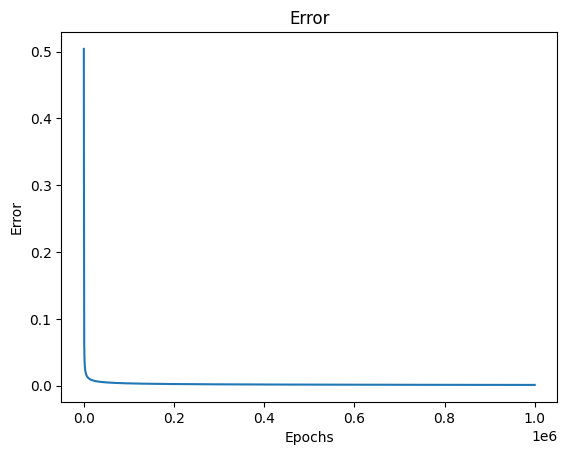

In [10]:
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()